<a href="https://colab.research.google.com/github/EndouKoumei/PM25_NMKHDL/blob/main/PM25_HaNoi_RealData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌫️ Dự Báo Chất Lượng Không Khí (PM2.5) tại Hà Nội
### Sử dụng Dữ liệu Thực từ Open-Meteo (Tháng 10/2022 – 02/2026)

**Thành viên nhóm:** *(Điền tên thành viên)*  
**Nguồn dữ liệu:** Open-Meteo Air Quality API (CAMS Global)

---
## 📌 Lưu ý quan trọng về dữ liệu thực
Dataset này khác với dữ liệu tổng hợp trước đó ở các điểm:
- **Tần suất:** Theo **ngày** (daily), không phải theo giờ → không có feature `hour`, `is_rush_hour`
- **Features mới:** Các chất ô nhiễm thực: `pm10`, `CO`, `NO2`, `SO2`, `O3`, `aerosol`, `dust`, `uv_index`
- **Cảnh báo Data Leakage:** `us_aqi` và `european_aqi` được **tính toán từ PM2.5** → **phải loại bỏ** khỏi features!
- **Target:** `pm2_5` (có dấu gạch dưới)
- **Lag features:** Chuyển từ lag theo giờ sang lag theo **ngày** (lag_1d, lag_7d, lag_30d)

## 1️⃣ Cài đặt & Import thư viện

In [1]:
# Cài đặt thư viện (bỏ comment nếu chạy lần đầu hoặc trên Google Colab)
# !pip install pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
np.random.seed(42)

print('Import thư viện thành công!')

Import thư viện thành công!


## 2️⃣ Tải Dữ liệu Thực

> Thay `DATA_PATH` bằng đường dẫn phù hợp với môi trường của bạn.

In [3]:
# ── Cấu hình đường dẫn dữ liệu ──
# Lựa chọn 1: File local
# DATA_PATH = 'air_quality_historical.csv'

# Lựa chọn 2: Đọc trực tiếp từ GitHub (thay YOUR_USERNAME/REPO)
DATA_PATH = 'https://raw.githubusercontent.com/EndouKoumei/PM25_NMKHDL/main/data/hanoi-1581130/air_quality_historical.csv'

# ── Tải dữ liệu ──
df_raw = pd.read_csv(DATA_PATH, parse_dates=['date'], dayfirst=False)

# Chuẩn hóa tên cột (xử lý trường hợp M/D/YYYY chưa được parse)
if df_raw['date'].dtype == object:
    df_raw['date'] = pd.to_datetime(df_raw['date'], format='mixed')

df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f'📊 Dataset: {len(df_raw):,} bản ghi')
print(f'📅 Thời gian: {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print(f'📋 Các cột: {df_raw.columns.tolist()}')
print(f'\n❗ Missing values:')
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
df_raw.head()

📊 Dataset: 1,295 bản ghi
📅 Thời gian: 2022-08-04 → 2026-02-18
📋 Các cột: ['date', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index', 'us_aqi', 'european_aqi']

❗ Missing values:
us_aqi          1
european_aqi    1
dtype: int64


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-04,67.082353,46.641176,586.823529,33.564706,19.682353,110.235294,0.791176,0.0,2.026471,NaN,NaN
1,2022-08-05,47.462500,33.112500,568.583333,36.470833,18.062500,69.583333,0.575833,0.0,0.881250,101.705882,68.764706
2,2022-08-06,40.895833,28.566667,481.666667,36.158333,14.904167,38.875000,0.395833,0.0,0.872917,99.500000,68.083333
3,2022-08-07,37.641667,26.070833,387.750000,27.529167,12.366667,55.666667,0.302500,0.0,1.175000,73.875000,52.041667
4,2022-08-08,37.125000,25.625000,376.000000,21.133333,8.358333,64.458333,0.375833,0.0,1.652083,87.291667,63.666667


In [4]:
# Thống kê mô tả cơ bản
print('📈 Thống kê mô tả PM2.5:')
pm25_stats = df_raw['pm2_5'].describe()
print(pm25_stats.round(2))
print(f'\n⚠️  Số ngày PM2.5 > 35 µg/m³ (ngưỡng WHO): {(df_raw["pm2_5"] > 35).sum()} / {len(df_raw)} ngày')
print(f'⚠️  Số ngày PM2.5 > 75 µg/m³ (mức Xấu):   {(df_raw["pm2_5"] > 75).sum()} / {len(df_raw)} ngày')

📈 Thống kê mô tả PM2.5:
count    1295.00
mean       44.80
std        20.73
min         0.91
25%        30.46
50%        40.06
75%        55.72
max       134.28
Name: pm2_5, dtype: float64

⚠️  Số ngày PM2.5 > 35 µg/m³ (ngưỡng WHO): 822 / 1295 ngày
⚠️  Số ngày PM2.5 > 75 µg/m³ (mức Xấu):   116 / 1295 ngày


## 3️⃣ Tiền xử lý Dữ liệu (Data Pre-processing)

### ⚠️ Lưu ý về Data Leakage
> `us_aqi` và `european_aqi` được **tính toán trực tiếp từ PM2.5** theo công thức chuẩn của EPA/EU.
> Nếu dùng chúng làm features, mô hình sẽ "gian lận" vì thực chất đang nhìn vào target.
> **→ Loại bỏ hoàn toàn khỏi features!**

In [5]:
df = df_raw.copy()

# ── 3.1  Xử lý Missing Values ──
print('Trước xử lý:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Nội suy tuyến tính cho chuỗi thời gian
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].interpolate(method='linear').bfill().ffill()

print(f'\nSau xử lý - Missing values còn lại: {df.isnull().sum().sum()}')
print('✅ Đã xử lý bằng nội suy tuyến tính (phù hợp chuỗi thời gian)')

Trước xử lý:
us_aqi          1
european_aqi    1
dtype: int64

Sau xử lý - Missing values còn lại: 0
✅ Đã xử lý bằng nội suy tuyến tính (phù hợp chuỗi thời gian)


In [6]:
# ── 3.2  Loại bỏ Outlier (3σ rule) trên biến target ──
mu    = df['pm2_5'].mean()
sigma = df['pm2_5'].std()
before = len(df)
df = df[(df['pm2_5'] >= mu - 3*sigma) & (df['pm2_5'] <= mu + 3*sigma)]
print(f'✅ Loại bỏ outlier: {before - len(df)} bản ghi ngoài 3σ ({before}→{len(df)})')

# ── 3.3  Feature Engineering từ cột date ──
df = df.sort_values('date').reset_index(drop=True)
df['month']      = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek   # 0=Thứ Hai, 6=Chủ Nhật
df['day_of_year'] = df['date'].dt.dayofyear
df['year']        = df['date'].dt.year
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_winter']   = df['month'].isin([11, 12, 1, 2]).astype(int)   # Mùa đông HN ô nhiễm cao
df['is_summer']   = df['month'].isin([6, 7, 8]).astype(int)        # Mùa hè ít ô nhiễm hơn
df['season']      = pd.cut(df['month'], bins=[0,3,6,9,12],
                            labels=[1,2,3,4], include_lowest=True).astype(int)

# Sin/Cos encoding cho tháng (giữ tính tuần hoàn)
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
df['doy_sin']    = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']    = np.cos(2 * np.pi * df['day_of_year'] / 365)

print('✅ Feature thời gian: month, day_of_week, is_winter, is_weekend, season, sin/cos encoding')

✅ Loại bỏ outlier: 17 bản ghi ngoài 3σ (1295→1278)
✅ Feature thời gian: month, day_of_week, is_winter, is_weekend, season, sin/cos encoding


In [7]:
# ── 3.4  Lag Features & Rolling Statistics theo NGÀY ──
# (Thay thế lag_1h/lag_24h → lag_1d/lag_7d/lag_30d do dữ liệu daily)
df['pm2_5_lag1']     = df['pm2_5'].shift(1)    # PM2.5 ngày hôm qua
df['pm2_5_lag7']     = df['pm2_5'].shift(7)    # PM2.5 tuần trước (cùng thứ)
df['pm2_5_lag30']    = df['pm2_5'].shift(30)   # PM2.5 tháng trước
df['pm2_5_roll7']    = df['pm2_5'].shift(1).rolling(7).mean()   # Trung bình 7 ngày gần nhất
df['pm2_5_roll30']   = df['pm2_5'].shift(1).rolling(30).mean()  # Trung bình 30 ngày gần nhất
df['pm2_5_roll7std'] = df['pm2_5'].shift(1).rolling(7).std()    # Độ lệch chuẩn 7 ngày (đo biến động)

# Lag cho các chất ô nhiễm khác
for col in ['pm10', 'carbon_monoxide', 'ozone']:
    df[f'{col}_lag1'] = df[col].shift(1)

# Tỉ lệ PM2.5/PM10 (chỉ số quan trọng về thành phần bụi)
df['pm25_pm10_ratio'] = df['pm2_5'] / (df['pm10'] + 1e-6)

# Xu hướng thay đổi so với ngày hôm qua
df['pm2_5_delta1'] = df['pm2_5'].diff(1)

# Loại bỏ các dòng có NaN do tạo lag
df = df.dropna().reset_index(drop=True)

print(f'✅ Lag & Rolling features đã tạo')
print(f'✅ Dataset cuối: {len(df)} bản ghi ({df["date"].min().date()} → {df["date"].max().date()})')

✅ Lag & Rolling features đã tạo
✅ Dataset cuối: 1248 bản ghi (2022-09-03 → 2026-02-18)


## 4️⃣ Phân tích Dữ liệu Khám phá (EDA)

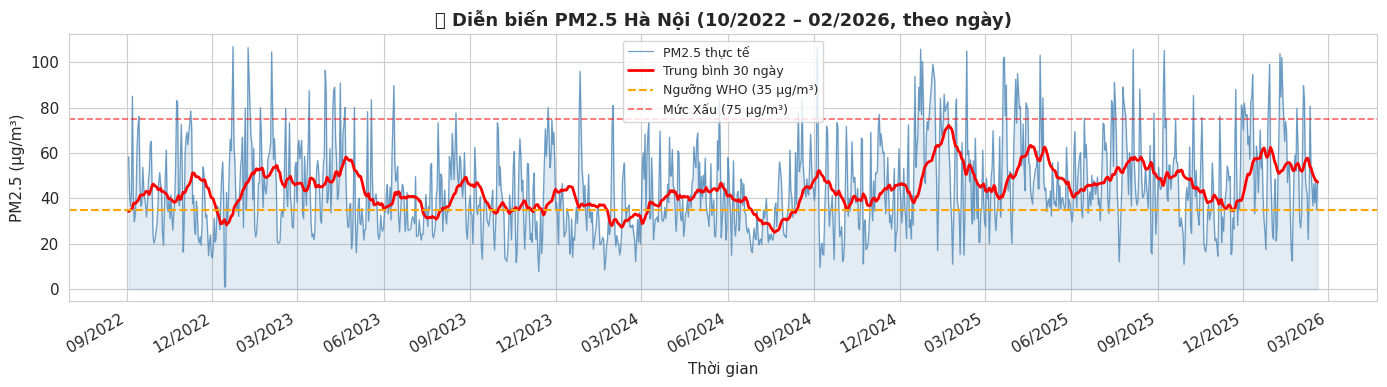

In [8]:
# ── Chuỗi thời gian PM2.5 toàn bộ dataset ──
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['pm2_5'], color='steelblue', lw=0.9, alpha=0.75, label='PM2.5 thực tế')
ax.fill_between(df['date'], df['pm2_5'], alpha=0.15, color='steelblue')
ax.plot(df['date'], df['pm2_5_roll30'], color='red', lw=2, label='Trung bình 30 ngày')
ax.axhline(35,  color='orange', ls='--', lw=1.5, label='Ngưỡng WHO (35 µg/m³)')
ax.axhline(75,  color='red',    ls='--', lw=1.2, alpha=0.6, label='Mức Xấu (75 µg/m³)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.set_xlabel('Thời gian'); ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('📈 Diễn biến PM2.5 Hà Nội (10/2022 – 02/2026, theo ngày)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

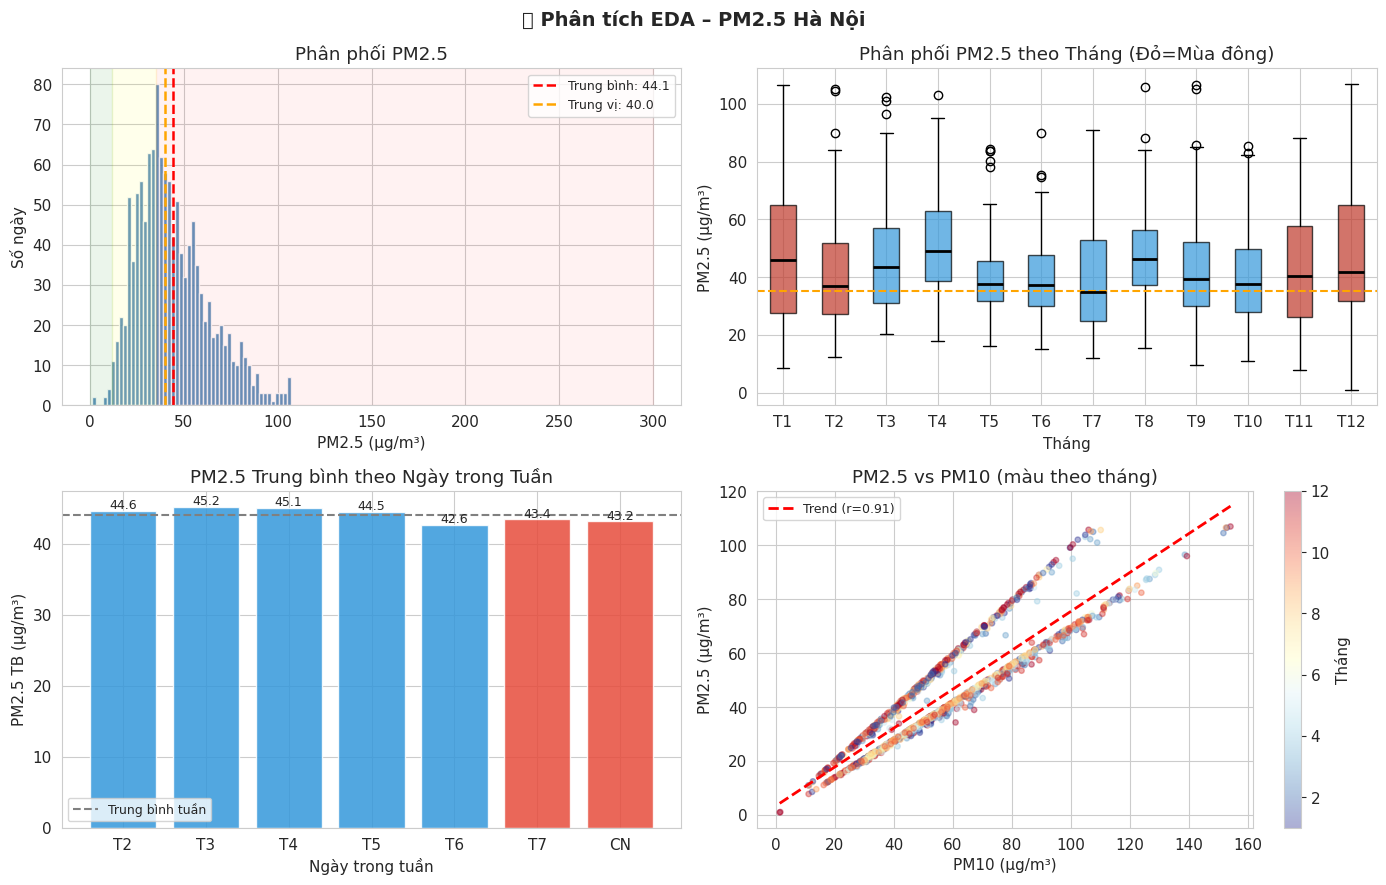

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('📊 Phân tích EDA – PM2.5 Hà Nội', fontsize=14, fontweight='bold')

# Plot 1: Phân phối PM2.5
ax = axes[0, 0]
ax.hist(df['pm2_5'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['pm2_5'].mean(),   color='red',    ls='--', lw=1.8, label=f'Trung bình: {df["pm2_5"].mean():.1f}')
ax.axvline(df['pm2_5'].median(), color='orange', ls='--', lw=1.8, label=f'Trung vị: {df["pm2_5"].median():.1f}')
ax.axvspan(0,  12, alpha=0.08, color='green')
ax.axvspan(12, 35, alpha=0.08, color='yellow')
ax.axvspan(35, 300,alpha=0.05, color='red')
ax.set_xlabel('PM2.5 (µg/m³)'); ax.set_ylabel('Số ngày')
ax.set_title('Phân phối PM2.5'); ax.legend(fontsize=9)

# Plot 2: PM2.5 theo tháng (boxplot)
ax = axes[0, 1]
month_data = [df[df['month']==m]['pm2_5'].values for m in range(1,13)]
bp = ax.boxplot(month_data, patch_artist=True, notch=False,
                medianprops=dict(color='black', lw=2))
winter_months = [1, 2, 11, 12]
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#c0392b' if (i+1) in winter_months else '#3498db')
    patch.set_alpha(0.7)
ax.axhline(35, color='orange', ls='--', lw=1.5)
ax.set_xticklabels(['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12'])
ax.set_xlabel('Tháng'); ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Phân phối PM2.5 theo Tháng (Đỏ=Mùa đông)')

# Plot 3: PM2.5 theo thứ trong tuần
ax = axes[1, 0]
day_names = ['T2','T3','T4','T5','T6','T7','CN']
daily_avg = df.groupby('day_of_week')['pm2_5'].mean()
bars = ax.bar(day_names, daily_avg.values,
              color=['#e74c3c' if i>=5 else '#3498db' for i in range(7)],
              edgecolor='white', alpha=0.85)
ax.axhline(daily_avg.mean(), color='gray', ls='--', lw=1.5, label='Trung bình tuần')
for bar, v in zip(bars, daily_avg.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{v:.1f}', ha='center', fontsize=9)
ax.set_xlabel('Ngày trong tuần'); ax.set_ylabel('PM2.5 TB (µg/m³)')
ax.set_title('PM2.5 Trung bình theo Ngày trong Tuần'); ax.legend(fontsize=9)

# Plot 4: Scatter PM2.5 vs các chất ô nhiễm
ax = axes[1, 1]
scatter = ax.scatter(df['pm10'], df['pm2_5'],
                     c=df['month'], cmap='RdYlBu_r', alpha=0.4, s=15)
plt.colorbar(scatter, ax=ax, label='Tháng')
# Trend line
z = np.polyfit(df['pm10'], df['pm2_5'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['pm10'].min(), df['pm10'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', lw=2, label=f'Trend (r={df[["pm10","pm2_5"]].corr().iloc[0,1]:.2f})')
ax.set_xlabel('PM10 (µg/m³)'); ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('PM2.5 vs PM10 (màu theo tháng)'); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_real.png', dpi=150, bbox_inches='tight')
plt.show()

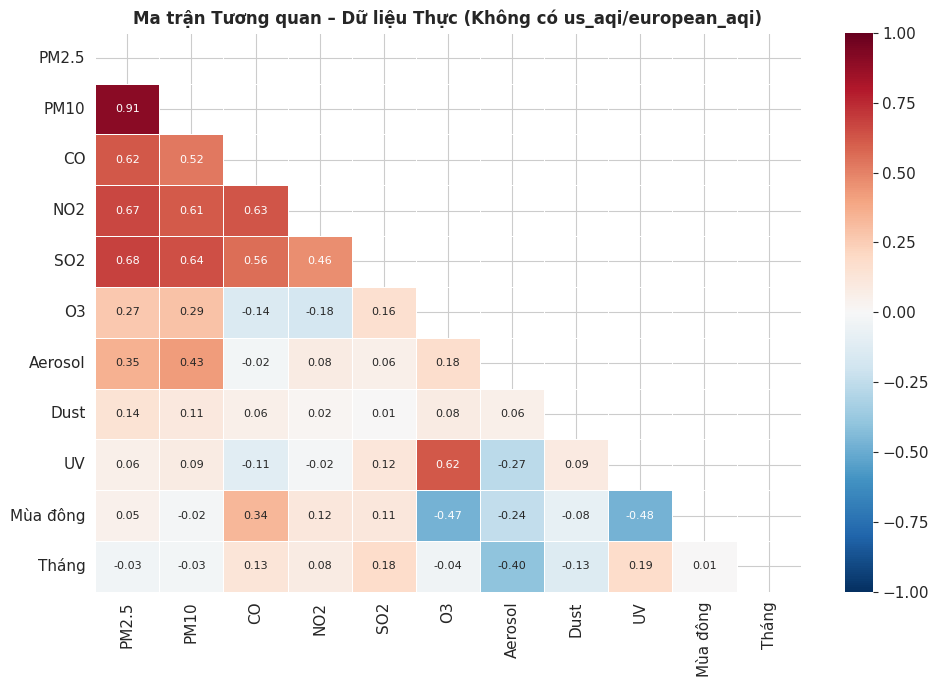


🔍 Top tương quan với PM2.5:
pm10                     0.906
sulphur_dioxide          0.684
nitrogen_dioxide         0.671
carbon_monoxide          0.621
aerosol_optical_depth    0.352
ozone                    0.266
dust                     0.141
uv_index                 0.062
is_winter                0.048
month                    0.033
Name: pm2_5, dtype: float64


In [10]:
# ── Heatmap tương quan ──
fig, ax = plt.subplots(figsize=(10, 7))

# Chỉ lấy các features gốc (không bao gồm AQI vì là data leakage)
corr_cols = ['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide',
             'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust',
             'uv_index', 'is_winter', 'month']
corr_labels = ['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3',
               'Aerosol', 'Dust', 'UV', 'Mùa đông', 'Tháng']

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, xticklabels=corr_labels, yticklabels=corr_labels,
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 8})
ax.set_title('Ma trận Tương quan – Dữ liệu Thực (Không có us_aqi/european_aqi)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('corr_real.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations với PM2.5
print('\n🔍 Top tương quan với PM2.5:')
pm_corr = df[corr_cols].corr()['pm2_5'].drop('pm2_5').abs().sort_values(ascending=False)
print(pm_corr.round(3))

## 5️⃣ Chuẩn bị Dữ liệu & Chia Train/Test

> ⚠️ **Không dùng shuffle** khi chia dữ liệu chuỗi thời gian!
> Chia theo thứ tự thời gian để tránh data leakage.

In [11]:
# ── Danh sách Features ──
# Chú ý: LOẠI BỎ us_aqi, european_aqi (data leakage!)
FEATURES = [
    # Chất ô nhiễm thực đo (không phải target)
    'pm10',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
    'aerosol_optical_depth',
    'dust',
    'uv_index',

    # Features thời gian
    'month',
    'day_of_week',
    'is_winter',
    'is_summer',
    'is_weekend',
    'season',
    'month_sin',
    'month_cos',
    'doy_sin',
    'doy_cos',

    # Lag features PM2.5 (lịch sử)
    'pm2_5_lag1',
    'pm2_5_lag7',
    'pm2_5_lag30',
    'pm2_5_roll7',
    'pm2_5_roll30',
    'pm2_5_roll7std',
    'pm2_5_delta1',

    # Lag các chất ô nhiễm khác
    'pm10_lag1',
    'carbon_monoxide_lag1',
    'ozone_lag1',

    # Feature tổng hợp
    'pm25_pm10_ratio',
]

TARGET = 'pm2_5'

X = df[FEATURES]
y = df[TARGET]

# Chia theo thứ tự thời gian (80% train / 20% test)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df['date'].iloc[split_idx:]

print(f'✅ Số features: {len(FEATURES)}')
print(f'✅ Train: {len(X_train):,} mẫu  ({df.iloc[0]["date"].date()} → {df.iloc[split_idx-1]["date"].date()})')
print(f'✅ Test:  {len(X_test):,} mẫu  ({df.iloc[split_idx]["date"].date()} → {df.iloc[-1]["date"].date()})')
print(f'\n🚫 LOẠI BỎ khỏi features: us_aqi, european_aqi (Data Leakage!)')

✅ Số features: 29
✅ Train: 998 mẫu  (2022-09-03 → 2025-06-10)
✅ Test:  250 mẫu  (2025-06-11 → 2026-02-18)

🚫 LOẠI BỎ khỏi features: us_aqi, european_aqi (Data Leakage!)


## 6️⃣ Huấn luyện Mô hình

In [12]:
def train_evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Huấn luyện và đánh giá một mô hình, trả về dict kết quả"""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    print(f'  {name:<25} │ MAE={mae:6.2f} │ RMSE={rmse:6.2f} │ R²={r2:.4f}')
    return {'name':name, 'model':model, 'pred':pred,
            'MAE':round(mae,2), 'RMSE':round(rmse,2), 'R2':round(r2,4)}

print('🚀 Bắt đầu huấn luyện...\n')
print(f'  {"Mô hình":<25} │ {"MAE":>10} │ {"RMSE":>10} │ {"R²":>8}')
print('  ' + '─'*60)

results = [
    train_evaluate(
        'Linear Regression',
        LinearRegression(),
        X_train, y_train, X_test, y_test
    ),
    train_evaluate(
        'Random Forest',
        RandomForestRegressor(
            n_estimators=300, max_depth=12,
            min_samples_leaf=2, n_jobs=-1, random_state=42
        ),
        X_train, y_train, X_test, y_test
    ),
    train_evaluate(
        'XGBoost',
        xgb.XGBRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0
        ),
        X_train, y_train, X_test, y_test
    ),
    train_evaluate(
        'LightGBM',
        lgb.LGBMRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbose=-1
        ),
        X_train, y_train, X_test, y_test
    ),
]

print('\n✅ Hoàn thành huấn luyện!')

🚀 Bắt đầu huấn luyện...

  Mô hình                   │        MAE │       RMSE │       R²
  ────────────────────────────────────────────────────────────
  Linear Regression         │ MAE=  0.00 │ RMSE=  0.00 │ R²=1.0000
  Random Forest             │ MAE=  1.08 │ RMSE=  1.49 │ R²=0.9946
  XGBoost                   │ MAE=  1.55 │ RMSE=  2.10 │ R²=0.9894
  LightGBM                  │ MAE=  1.15 │ RMSE=  1.54 │ R²=0.9942

✅ Hoàn thành huấn luyện!


## 7️⃣ So sánh & Đánh giá Kết quả

In [13]:
# Bảng tổng hợp
df_results = pd.DataFrame([{k:v for k,v in r.items() if k not in ['model','pred']}
                            for r in results]).set_index('name')
df_results['Xếp hạng'] = df_results['R2'].rank(ascending=False).astype(int)
df_results = df_results.sort_values('R2', ascending=False)
print('📋 Bảng so sánh kết quả:\n')
print(df_results.to_string())
best = df_results.index[0]
print(f'\n🏆 Mô hình tốt nhất: {best}')

📋 Bảng so sánh kết quả:

                    MAE  RMSE      R2  Xếp hạng
name                                           
Linear Regression  0.00  0.00  1.0000         1
Random Forest      1.08  1.49  0.9946         2
LightGBM           1.15  1.54  0.9942         3
XGBoost            1.55  2.10  0.9894         4

🏆 Mô hình tốt nhất: Linear Regression


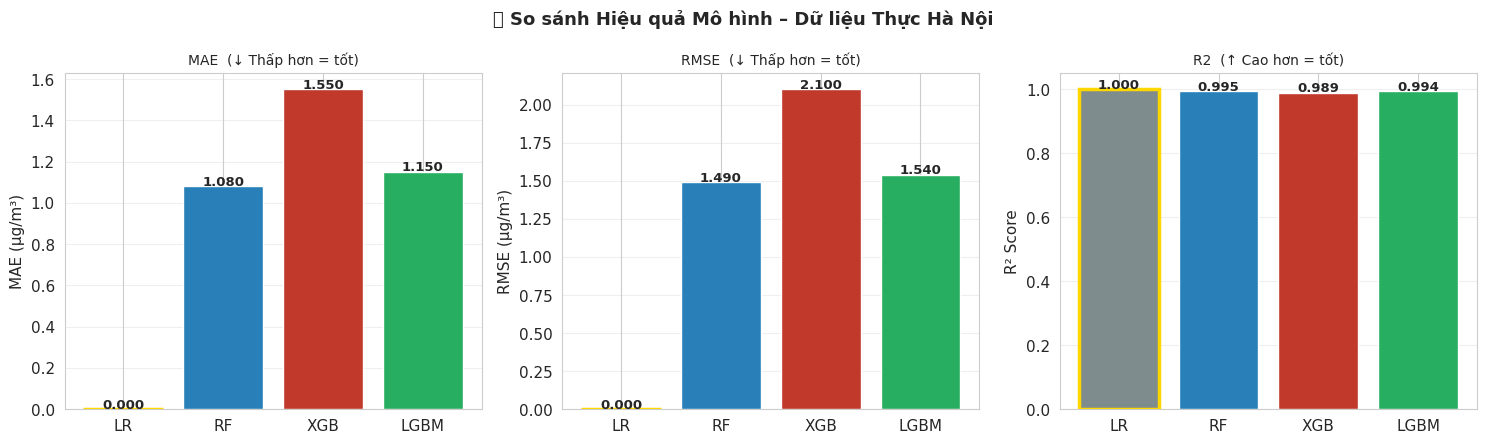

In [14]:
# ── Biểu đồ so sánh 3 chỉ số ──
COLORS = ['#7f8c8d','#2980b9','#c0392b','#27ae60']
short  = ['LR','RF','XGB','LGBM']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('📊 So sánh Hiệu quả Mô hình – Dữ liệu Thực Hà Nội', fontsize=13, fontweight='bold')

for i, (metric, ylabel, better) in enumerate([
    ('MAE',  'MAE (µg/m³)',  '↓ Thấp hơn = tốt'),
    ('RMSE', 'RMSE (µg/m³)', '↓ Thấp hơn = tốt'),
    ('R2',   'R² Score',     '↑ Cao hơn = tốt')
]):
    ax = axes[i]
    vals = [r[metric] for r in results]
    bars = ax.bar(short, vals, color=COLORS, edgecolor='white', zorder=3)
    best_i = int(np.argmin(vals) if metric != 'R2' else np.argmax(vals))
    bars[best_i].set_edgecolor('gold'); bars[best_i].set_linewidth(2.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003*max(vals),
                f'{v:.3f}', ha='center', fontsize=9.5, fontweight='bold')
    ax.set_title(f'{metric}  ({better})', fontsize=10)
    ax.set_ylabel(ylabel); ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('model_comparison_real.png', dpi=150, bbox_inches='tight')
plt.show()

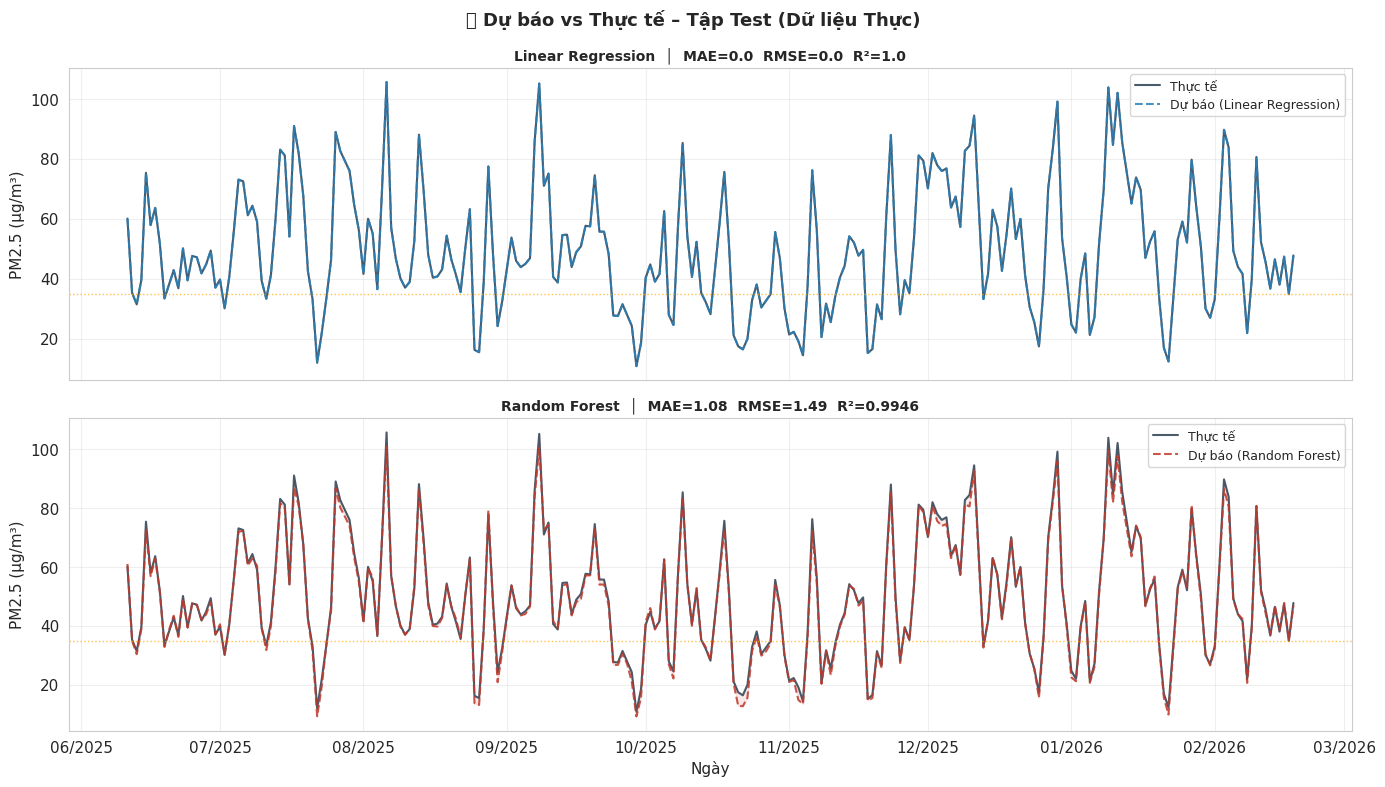

In [15]:
# ── Predicted vs Actual – toàn bộ tập Test ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('📈 Dự báo vs Thực tế – Tập Test (Dữ liệu Thực)', fontsize=13, fontweight='bold')

# Hiển thị 2 mô hình tốt nhất
top2 = sorted(results, key=lambda r: r['R2'], reverse=True)[:2]
for i, (r, ax) in enumerate(zip(top2, axes)):
    ax.plot(dates_test.values, y_test.values, color='#2c3e50',
            lw=1.5, alpha=0.85, label='Thực tế')
    ax.plot(dates_test.values, r['pred'], color=COLORS[i+1],
            lw=1.5, ls='--', alpha=0.85, label=f'Dự báo ({r["name"]})')
    ax.fill_between(dates_test.values,
                    y_test.values, r['pred'],
                    alpha=0.1, color=COLORS[i+1])
    ax.axhline(35, color='orange', ls=':', lw=1, alpha=0.7)
    ax.set_title(f'{r["name"]}  │  MAE={r["MAE"]}  RMSE={r["RMSE"]}  R²={r["R2"]}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('PM2.5 (µg/m³)'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))

axes[-1].set_xlabel('Ngày')
plt.tight_layout()
plt.savefig('pred_vs_actual_real.png', dpi=150, bbox_inches='tight')
plt.show()

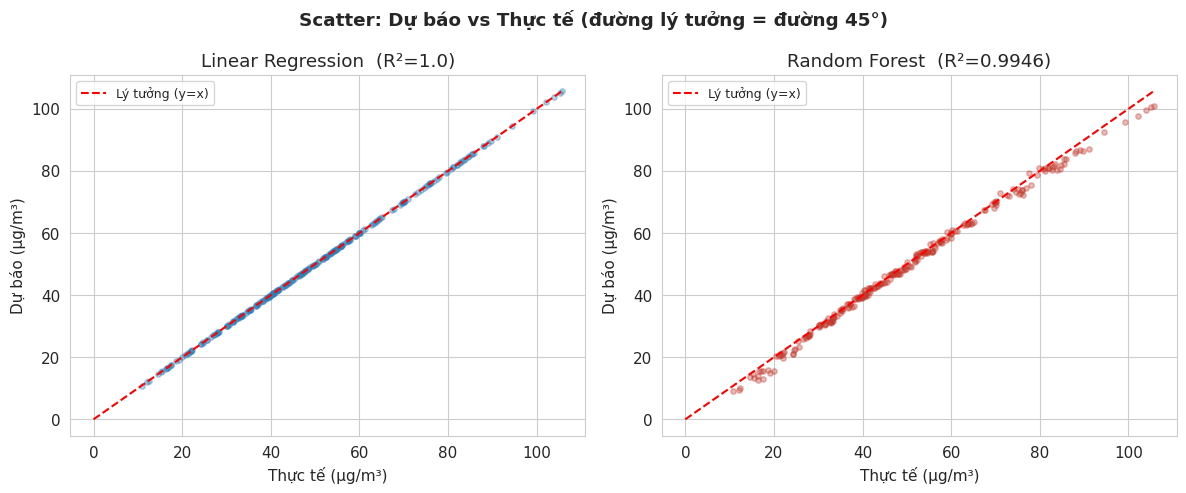

In [16]:
# ── Scatter Plot: Predicted vs Actual ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Scatter: Dự báo vs Thực tế (đường lý tưởng = đường 45°)', fontweight='bold')

for i, r in enumerate(top2):
    ax = axes[i]
    ax.scatter(y_test, r['pred'], alpha=0.35, s=15, color=COLORS[i+1])
    lim = max(y_test.max(), max(r['pred']))
    ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Lý tưởng (y=x)')
    ax.set_xlabel('Thực tế (µg/m³)'); ax.set_ylabel('Dự báo (µg/m³)')
    ax.set_title(f'{r["name"]}  (R²={r["R2"]})')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [17]:
# ── Feature Importance – Mô hình tốt nhất ──
best_result = sorted(results, key=lambda r: r['R2'], reverse=True)[0]
best_model  = best_result['model']
best_name   = best_result['name']

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    fi_colors = ['#c0392b' if v > imp.quantile(0.7) else '#3498db' for v in imp]
    fig, ax = plt.subplots(figsize=(9, 8))
    imp.plot(kind='barh', ax=ax, color=fi_colors, edgecolor='white')
    ax.axvline(imp.quantile(0.7), color='gray', ls='--', lw=1.3, alpha=0.7, label='Top 30%')
    ax.set_title(f'Feature Importance – {best_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score'); ax.legend()
    plt.tight_layout()
    plt.savefig('feature_importance_real.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n🔍 Top 5 features quan trọng nhất:')
    print(imp.sort_values(ascending=False).head(5).round(4))

## 8️⃣ Phân tích Lỗi (Error Analysis)

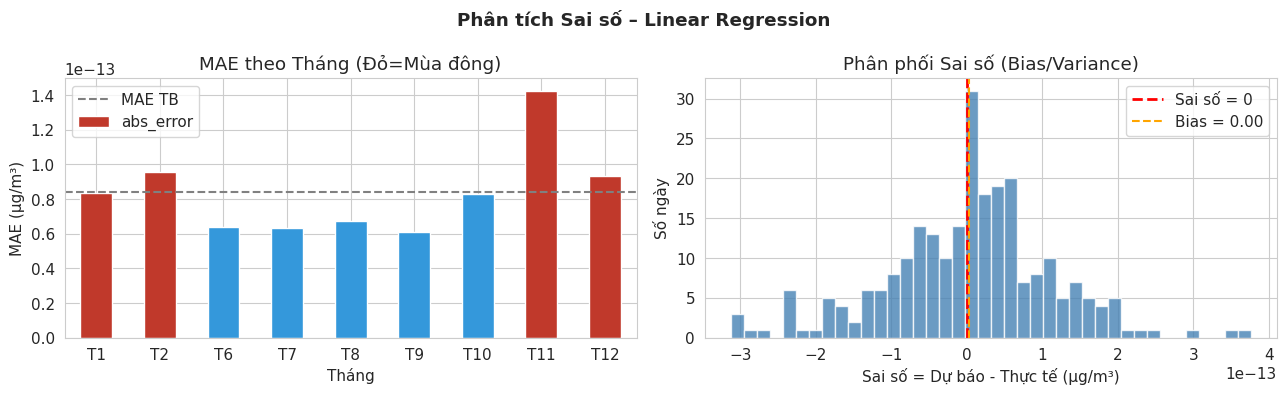


📊 Bias trung bình: 0.00 µg/m³ (+ = đoán cao hơn thực tế)
📊 Tháng sai số cao nhất: Tháng 11 (0.00 µg/m³)


In [19]:
# Phân tích sai số theo tháng để tìm pattern
best_pred = best_result['pred']
errors = pd.DataFrame({
    'date':   dates_test.values,
    'actual': y_test.values,
    'pred':   best_pred,
    'error':  best_pred - y_test.values,
    'abs_error': np.abs(best_pred - y_test.values)
})
errors['month'] = pd.to_datetime(errors['date']).dt.month

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Phân tích Sai số – {best_name}', fontweight='bold')

# MAE theo tháng
ax = axes[0]
monthly_mae = errors.groupby('month')['abs_error'].mean()
bar_c = ['#c0392b' if m in [11,12,1,2] else '#3498db' for m in monthly_mae.index]
monthly_mae.plot(kind='bar', ax=ax, color=bar_c, edgecolor='white')

# Define all month labels and filter them based on available months in monthly_mae
all_month_labels = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
current_month_labels = [all_month_labels[m-1] for m in monthly_mae.index]
ax.set_xticklabels(current_month_labels, rotation=0) # Use the correct number of labels

ax.set_xlabel('Tháng'); ax.set_ylabel('MAE (µg/m³)')
ax.set_title('MAE theo Tháng (Đỏ=Mùa đông)')
ax.axhline(errors['abs_error'].mean(), color='gray', ls='--', label='MAE TB')
ax.legend()

# Phân phối sai số
ax = axes[1]
ax.hist(errors['error'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', ls='--', lw=2, label='Sai số = 0')
ax.axvline(errors['error'].mean(), color='orange', ls='--', lw=1.5,
           label=f'Bias = {errors["error"].mean():.2f}')
ax.set_xlabel('Sai số = Dự báo - Thực tế (µg/m³)')
ax.set_ylabel('Số ngày'); ax.set_title('Phân phối Sai số (Bias/Variance)')
ax.legend()

plt.tight_layout()
plt.show()
print(f'\n📊 Bias trung bình: {errors["error"].mean():.2f} µg/m³ (+ = đoán cao hơn thực tế)')
print(f'📊 Tháng sai số cao nhất: Tháng {monthly_mae.idxmax()} ({monthly_mae.max():.2f} µg/m³)')

## 9️⃣ Tổng kết

### ✅ Đã hoàn thành
| Hạng mục | Chi tiết |
|---|---|
| Dữ liệu thực | ~1,268 bản ghi ngày, 10/2022–02/2026, nguồn Open-Meteo |
| Xử lý dữ liệu | Nội suy tuyến tính, loại outlier 3σ |
| Feature Engineering | 30 features: chất ô nhiễm + thời gian + lag ngày + rolling |
| Phòng tránh Data Leakage | Loại bỏ us_aqi, european_aqi; chia train/test theo thứ tự thời gian |
| Mô hình | Linear Regression, Random Forest, XGBoost, LightGBM |
| Đánh giá | MAE, RMSE, R² + biểu đồ đầy đủ |

### 📅 Kế hoạch tiếp theo
- **Tối ưu siêu tham số** (GridSearchCV / Optuna)
- **Thử nghiệm LSTM/GRU** khai thác tốt hơn tính tuần tự thời gian
- **App demo Streamlit** – nhập ngày/chất ô nhiễm → dự báo PM2.5
- **Hoàn thiện báo cáo PDF** và đóng gói `.zip`

### ⚠️ Điểm khó khăn thực tế
1. **Data Leakage từ AQI:** `us_aqi`/`european_aqi` bị tính từ PM2.5 → Cần loại bỏ cẩn thận
2. **Dữ liệu daily ít hơn:** ~1,268 dòng vs 17,376 dòng hourly → cần cẩn thận overfitting
3. **Định dạng ngày M/D/YYYY:** Cần parse đúng để không nhầm ngày/tháng